# The World’s Mood Map: Can News Tone Predict Protests, Conflict, and Diplomacy?

**Course:** Python Data Analytics  
**Dataset:** GDELT 2.0 Event Database  
**Core idea:** Use global news event data to explore whether media tone, event type, actor countries, and attention metrics can reveal patterns of protest, conflict, and diplomacy.

## Research Questions

1. Do countries with more negative news tone experience more conflict-related events?
2. Which event types attract the most international media attention?
3. Are diplomatic events reported with a different tone than protest or conflict events?
4. How does global event intensity change across days, weeks, and hours?
5. Can we build a simple descriptive **Global Tension Index** from news tone, event severity, and media attention?

## Data Source

GDELT 2.0 master file list:  
`http://data.gdeltproject.org/gdeltv2/masterfilelist.txt`

GDELT 2.0 event files are ZIP files ending in:  
`.export.CSV.zip`

> Important: GDELT is very large. This notebook downloads a sample of recent files, enough for a strong academic project without downloading the whole database.

**Implementation note:** The revised notebook keeps the analysis focused on lecture-style tools: pandas, numpy, matplotlib, and seaborn. Advanced interactive maps and machine learning clustering were removed to stay aligned with the provided course material.


In [1]:
# ============================================================
# Cell 1: Import libraries
# ============================================================

import os
import re
import zipfile
import warnings
from pathlib import Path

import requests
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 50)

# Consistent graph size/style used in the professor-style lecture notebook
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "figure.dpi": 100
})

print("Libraries loaded successfully.")


/Users/beltinaa/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Libraries loaded successfully.


In [2]:
# ============================================================
# Cell 2: Project configuration
# ============================================================

# GDELT updates every 15 minutes, so many files are available per day.

MASTER_FILE_URL = "http://data.gdeltproject.org/gdeltv2/masterfilelist.txt"

# Number of recent GDELT export files to download.
# 8 to 20 files is usually enough for thousands of rows.
MAX_FILES = 12

TARGET_COUNTRIES = None

# Minimum rows expected for the project.
MIN_ROWS_REQUIRED = 1000

# Folder to store downloaded files
DATA_DIR = Path("gdelt_data")
DATA_DIR.mkdir(exist_ok=True)

print("Configuration complete.")
print(f"Data folder: {DATA_DIR.resolve()}")

Configuration complete.
Data folder: /Users/beltinaa/Downloads/gdelt_data


## GDELT 2.0 Event Column Names

Raw GDELT `.export.CSV.zip` files do **not always include a header row**, so we define the official event schema manually.

The most important variables for this project are:

- `AvgTone`: average tone of news coverage
- `GoldsteinScale`: event cooperation/conflict score
- `QuadClass`: broad class of event
- `NumMentions`: how often the event is mentioned
- `NumSources`: number of sources covering the event
- `ActionGeo_CountryCode`: country where the event action happened
- `EventRootCode`: high-level event type
- `SQLDATE`: event date

In [3]:
# ============================================================
# Cell 3: Define GDELT 2.0 event column names
# ============================================================

GDELT_COLUMNS = [
    "GLOBALEVENTID", "SQLDATE", "MonthYear", "Year", "FractionDate",
    "Actor1Code", "Actor1Name", "Actor1CountryCode", "Actor1KnownGroupCode",
    "Actor1EthnicCode", "Actor1Religion1Code", "Actor1Religion2Code",
    "Actor1Type1Code", "Actor1Type2Code", "Actor1Type3Code",
    "Actor2Code", "Actor2Name", "Actor2CountryCode", "Actor2KnownGroupCode",
    "Actor2EthnicCode", "Actor2Religion1Code", "Actor2Religion2Code",
    "Actor2Type1Code", "Actor2Type2Code", "Actor2Type3Code",
    "IsRootEvent", "EventCode", "EventBaseCode", "EventRootCode",
    "QuadClass", "GoldsteinScale", "NumMentions", "NumSources",
    "NumArticles", "AvgTone",
    "Actor1Geo_Type", "Actor1Geo_Fullname", "Actor1Geo_CountryCode",
    "Actor1Geo_ADM1Code", "Actor1Geo_ADM2Code", "Actor1Geo_Lat",
    "Actor1Geo_Long", "Actor1Geo_FeatureID",
    "Actor2Geo_Type", "Actor2Geo_Fullname", "Actor2Geo_CountryCode",
    "Actor2Geo_ADM1Code", "Actor2Geo_ADM2Code", "Actor2Geo_Lat",
    "Actor2Geo_Long", "Actor2Geo_FeatureID",
    "ActionGeo_Type", "ActionGeo_Fullname", "ActionGeo_CountryCode",
    "ActionGeo_ADM1Code", "ActionGeo_ADM2Code", "ActionGeo_Lat",
    "ActionGeo_Long", "ActionGeo_FeatureID",
    "DATEADDED", "SOURCEURL"
]

# We only load the columns needed for the project to save memory.
USE_COLUMNS = [
    "GLOBALEVENTID", "SQLDATE", "MonthYear", "Year",
    "Actor1Name", "Actor1CountryCode",
    "Actor2Name", "Actor2CountryCode",
    "EventCode", "EventBaseCode", "EventRootCode", "QuadClass",
    "GoldsteinScale", "NumMentions", "NumSources", "NumArticles", "AvgTone",
    "ActionGeo_CountryCode", "ActionGeo_Fullname", "ActionGeo_Lat", "ActionGeo_Long",
    "DATEADDED", "SOURCEURL"
]

print(f"Total schema columns: {len(GDELT_COLUMNS)}")
print(f"Columns used in this notebook: {len(USE_COLUMNS)}")

Total schema columns: 61
Columns used in this notebook: 23


In [5]:
# ============================================================
# Cell 4: Download master file list and select recent export files
# ============================================================

def fetch_master_file_list(master_url: str) -> pd.DataFrame:
    """Download GDELT masterfilelist.txt and return only export CSV zip files."""
    response = requests.get(master_url, timeout=60)
    response.raise_for_status()

    rows = []
    for line in response.text.splitlines():
        parts = line.strip().split()
        if len(parts) >= 3:
            size, md5, url = parts[0], parts[1], parts[2]
            if url.endswith(".export.CSV.zip"):
                filename = url.split("/")[-1]
                timestamp_match = re.search(r"(\d{14})\.export\.CSV\.zip", filename)
                if timestamp_match:
                    timestamp = pd.to_datetime(timestamp_match.group(1), format="%Y%m%d%H%M%S")
                    rows.append({
                        "size_bytes": int(size),
                        "md5": md5,
                        "url": url,
                        "filename": filename,
                        "timestamp": timestamp
                    })

    df_files = pd.DataFrame(rows).sort_values("timestamp")
    return df_files

files_df = fetch_master_file_list(MASTER_FILE_URL)

print("Available GDELT export files:", len(files_df))
print("Date range:", files_df["timestamp"].min(), "to", files_df["timestamp"].max())
files_df.tail()

Available GDELT export files: 386751
Date range: 2015-02-18 23:00:00 to 2026-05-16 13:15:00


,size_bytes,md5,url,filename,timestamp
386746,35223,680a55c34ea2f88a81983d11080695da,http://data.gdeltproject.org/gdeltv2/202605161...,20260516121500.export.CSV.zip,2026-05-16 12:15:00
386747,48906,41ac609f806fe2da9754af14977f7e72,http://data.gdeltproject.org/gdeltv2/202605161...,20260516123000.export.CSV.zip,2026-05-16 12:30:00
386748,41066,f1bedc33b1681645d233d46e7ee09098,http://data.gdeltproject.org/gdeltv2/202605161...,20260516124500.export.CSV.zip,2026-05-16 12:45:00
386749,51228,6e2afe2c797a6e7bec0d483a48ef4159,http://data.gdeltproject.org/gdeltv2/202605161...,20260516130000.export.CSV.zip,2026-05-16 13:00:00
386750,53685,ed8fed6916a42940a08d5e3ec62addf6,http://data.gdeltproject.org/gdeltv2/202605161...,20260516131500.export.CSV.zip,2026-05-16 13:15:00


In [6]:
# ============================================================
# Cell 5: Choose recent files to download
# ============================================================

selected_files = files_df.tail(MAX_FILES).copy()

print(f"Selected {len(selected_files)} recent export files.")
selected_files[["timestamp", "size_bytes", "url"]].head()

Selected 12 recent export files.


,timestamp,size_bytes,url
386739,2026-05-16 10:30:00,54403,http://data.gdeltproject.org/gdeltv2/202605161...
386740,2026-05-16 10:45:00,51188,http://data.gdeltproject.org/gdeltv2/202605161...
386741,2026-05-16 11:00:00,41728,http://data.gdeltproject.org/gdeltv2/202605161...
386742,2026-05-16 11:15:00,51782,http://data.gdeltproject.org/gdeltv2/202605161...
386743,2026-05-16 11:30:00,49497,http://data.gdeltproject.org/gdeltv2/202605161...


In [7]:
# ============================================================
# Cell 6: Download and read selected GDELT ZIP files
# ============================================================

def download_and_read_gdelt_file(url: str, data_dir: Path) -> pd.DataFrame:
    """Download one GDELT export ZIP file and read it into a DataFrame."""
    filename = url.split("/")[-1]
    local_zip_path = data_dir / filename

    # Download only if not already present
    if not local_zip_path.exists():
        print(f"Downloading {filename}...")
        response = requests.get(url, timeout=120)
        response.raise_for_status()
        local_zip_path.write_bytes(response.content)
    else:
        print(f"Using cached file: {filename}")

    # Read zipped CSV
    with zipfile.ZipFile(local_zip_path, "r") as z:
        csv_name = z.namelist()[0]
        with z.open(csv_name) as f:
            df = pd.read_csv(
                f,
                sep="\t",
                header=None,
                names=GDELT_COLUMNS,
                usecols=USE_COLUMNS,
                dtype={
                    "GLOBALEVENTID": "Int64",
                    "SQLDATE": "Int64",
                    "Year": "Int64",
                    "QuadClass": "Int64",
                    "EventRootCode": "string",
                    "EventCode": "string",
                    "EventBaseCode": "string",
                    "Actor1CountryCode": "string",
                    "Actor2CountryCode": "string",
                    "ActionGeo_CountryCode": "string",
                    "Actor1Name": "string",
                    "Actor2Name": "string",
                    "ActionGeo_Fullname": "string",
                    "SOURCEURL": "string"
                },
                encoding="latin1",
                low_memory=False
            )
    return df

frames = []

for_url_count = 0
for url in selected_files["url"]:
    try:
        frames.append(download_and_read_gdelt_file(url, DATA_DIR))
        for_url_count += 1
    except Exception as e:
        print(f"Failed to process {url}: {e}")

raw_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print(f"Files successfully loaded: {for_url_count}")
print(f"Raw rows loaded: {len(raw_df):,}")
raw_df.head()

Files successfully loaded: 12
Raw rows loaded: 10,293


,GLOBALEVENTID,SQLDATE,MonthYear,Year,Actor1Name,Actor1CountryCode,Actor2Name,Actor2CountryCode,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,ActionGeo_Fullname,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,DATEADDED,SOURCEURL
0,1304404227,20250516,202505,2025,AUSTRALIA,AUS,<NA>,<NA>,030,030,03,1,4.0,8,1,8,0.562430,"Cranbourne, Victoria, Australia",AS,-38.1134,145.2830,20260516103000,https://metro.co.uk/2026/05/16/kate-wills-payi...
1,1304404228,20250516,202505,2025,RESIDENTS,<NA>,HAWAII,USA,071,071,07,2,7.4,5,1,5,-6.005587,"Hawaii, United States",US,21.1098,-157.5310,20260516103000,https://www.hawaiitribune-herald.com/2026/05/1...
2,1304404229,20250516,202505,2025,RESIDENTS,<NA>,HAWAII,USA,111,111,11,3,-2.0,8,1,8,-6.005587,"Hawaii, United States",US,21.1098,-157.5310,20260516103000,https://www.hawaiitribune-herald.com/2026/05/1...
3,1304404230,20250516,202505,2025,ADMINISTRATION,<NA>,TAIWAN,TWN,060,060,06,2,6.0,3,1,3,-2.436054,Taiwan,TW,24.0000,121.0000,20260516103000,https://www.graphic.com.gh/international/inter...
4,1304404231,20250516,202505,2025,THE WHITE HOUSE,USA,<NA>,<NA>,173,173,17,4,-5.0,1,1,1,-6.476684,"Georgia, United States",US,32.9866,-83.6487,20260516103000,https://www.hawaiitribune-herald.com/2026/05/1...


In [8]:
# ============================================================
# Cell 7: Basic cleaning and feature engineering
# ============================================================

df = raw_df.copy()

# Convert dates
df["event_date"] = pd.to_datetime(df["SQLDATE"].astype(str), format="%Y%m%d", errors="coerce")
df["dateadded"] = pd.to_datetime(df["DATEADDED"].astype(str), format="%Y%m%d%H%M%S", errors="coerce")

# Numeric conversion
numeric_cols = [
    "GoldsteinScale", "NumMentions", "NumSources", "NumArticles",
    "AvgTone", "ActionGeo_Lat", "ActionGeo_Long"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing essential analysis variables
essential_cols = ["event_date", "QuadClass", "GoldsteinScale", "NumMentions", "NumSources", "AvgTone"]
df = df.dropna(subset=essential_cols)

# Optional country filtering
if TARGET_COUNTRIES is not None:
    df = df[df["ActionGeo_CountryCode"].isin(TARGET_COUNTRIES)]

# Add readable QuadClass labels
quad_labels = {
    1: "Verbal Cooperation",
    2: "Material Cooperation",
    3: "Verbal Conflict",
    4: "Material Conflict"
}

df["quad_label"] = df["QuadClass"].map(quad_labels)

# Simplified event category
def classify_event(row):
    root = str(row["EventRootCode"]).zfill(2)
    quad = row["QuadClass"]

    if quad in [3, 4]:
        if root in ["14"]:
            return "Protest"
        elif root in ["18", "19", "20"]:
            return "Conflict / Violence"
        elif root in ["17"]:
            return "Coercion"
        else:
            return "Other Conflict"
    elif quad in [1, 2]:
        if root in ["03", "04"]:
            return "Diplomacy / Consultation"
        elif root in ["05"]:
            return "Engagement / Cooperation"
        elif root in ["06", "07"]:
            return "Material Cooperation"
        else:
            return "Other Cooperation"
    else:
        return "Other"

df["event_category"] = df.apply(classify_event, axis=1)

# Attention score: combines mentions, sources, and articles.
# log1p prevents very large media spikes from dominating everything.
df["attention_score"] = (
    np.log1p(df["NumMentions"]) +
    np.log1p(df["NumSources"]) +
    np.log1p(df["NumArticles"])
)

# Negative tone strength
df["negative_tone"] = np.where(df["AvgTone"] < 0, abs(df["AvgTone"]), 0)

# Conflict flag
df["is_conflict"] = df["QuadClass"].isin([3, 4]).astype(int)
df["is_material_conflict"] = (df["QuadClass"] == 4).astype(int)
df["is_diplomacy"] = df["event_category"].isin(["Diplomacy / Consultation", "Engagement / Cooperation"]).astype(int)
df["is_protest"] = (df["event_category"] == "Protest").astype(int)

# Time features
df["hour_added"] = df["dateadded"].dt.hour
df["weekday"] = df["event_date"].dt.day_name()
df["week"] = df["event_date"].dt.to_period("W").astype(str)

print(f"Cleaned rows: {len(df):,}")

if len(df) < MIN_ROWS_REQUIRED:
    print("WARNING: The dataset has fewer rows than required. Increase MAX_FILES and rerun the download cells.")

df.head()

Cleaned rows: 10,293


,GLOBALEVENTID,SQLDATE,MonthYear,Year,Actor1Name,Actor1CountryCode,Actor2Name,Actor2CountryCode,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,ActionGeo_Fullname,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,DATEADDED,SOURCEURL,event_date,dateadded,quad_label,event_category,attention_score,negative_tone,is_conflict,is_material_conflict,is_diplomacy,is_protest,hour_added,weekday,week
0,1304404227,20250516,202505,2025,AUSTRALIA,AUS,<NA>,<NA>,030,030,03,1,4.0,8,1,8,0.562430,"Cranbourne, Victoria, Australia",AS,-38.1134,145.2830,20260516103000,https://metro.co.uk/2026/05/16/kate-wills-payi...,2025-05-16,2026-05-16 10:30:00,Verbal Cooperation,Diplomacy / Consultation,5.087596,0.000000,0,0,1,0,10,Friday,2025-05-12/2025-05-18
1,1304404228,20250516,202505,2025,RESIDENTS,<NA>,HAWAII,USA,071,071,07,2,7.4,5,1,5,-6.005587,"Hawaii, United States",US,21.1098,-157.5310,20260516103000,https://www.hawaiitribune-herald.com/2026/05/1...,2025-05-16,2026-05-16 10:30:00,Material Cooperation,Material Cooperation,4.276666,6.005587,0,0,0,0,10,Friday,2025-05-12/2025-05-18
2,1304404229,20250516,202505,2025,RESIDENTS,<NA>,HAWAII,USA,111,111,11,3,-2.0,8,1,8,-6.005587,"Hawaii, United States",US,21.1098,-157.5310,20260516103000,https://www.hawaiitribune-herald.com/2026/05/1...,2025-05-16,2026-05-16 10:30:00,Verbal Conflict,Other Conflict,5.087596,6.005587,1,0,0,0,10,Friday,2025-05-12/2025-05-18
3,1304404230,20250516,202505,2025,ADMINISTRATION,<NA>,TAIWAN,TWN,060,060,06,2,6.0,3,1,3,-2.436054,Taiwan,TW,24.0000,121.0000,20260516103000,https://www.graphic.com.gh/international/inter...,2025-05-16,2026-05-16 10:30:00,Material Cooperation,Material Cooperation,3.465736,2.436054,0,0,0,0,10,Friday,2025-05-12/2025-05-18
4,1304404231,20250516,202505,2025,THE WHITE HOUSE,USA,<NA>,<NA>,173,173,17,4,-5.0,1,1,1,-6.476684,"Georgia, United States",US,32.9866,-83.6487,20260516103000,https://www.hawaiitribune-herald.com/2026/05/1...,2025-05-16,2026-05-16 10:30:00,Material Conflict,Coercion,2.079442,6.476684,1,1,0,0,10,Friday,2025-05-12/2025-05-18


In [9]:
# ============================================================
# Cell 8: Dataset quality check
# ============================================================

print("Shape:", df.shape)
print("\nMissing values in selected columns:")
print(df[USE_COLUMNS].isna().mean().sort_values(ascending=False).head(15))

print("\nEvent date range:")
print(df["event_date"].min(), "to", df["event_date"].max())

print("\nUnique countries:", df["ActionGeo_CountryCode"].nunique())
print("\nQuadClass distribution:")
print(df["quad_label"].value_counts(dropna=False))

Shape: (10293, 36)

Missing values in selected columns:
Actor2CountryCode        0.521325
Actor1CountryCode        0.426115
Actor2Name               0.267852
Actor1Name               0.087438
ActionGeo_Long           0.023900
ActionGeo_Lat            0.023900
ActionGeo_Fullname       0.023900
ActionGeo_CountryCode    0.023900
GLOBALEVENTID            0.000000
NumSources               0.000000
DATEADDED                0.000000
AvgTone                  0.000000
NumArticles              0.000000
QuadClass                0.000000
NumMentions              0.000000
dtype: float64

Event date range:
2016-05-18 00:00:00 to 2026-05-16 00:00:00

Unique countries: 152

QuadClass distribution:
quad_label
Verbal Cooperation      6497
Material Conflict       1461
Verbal Conflict         1338
Material Cooperation     997
Name: count, dtype: int64


In [10]:
# ============================================================
# Cell 9: Descriptive statistics
# ============================================================

summary_cols = ["AvgTone", "GoldsteinScale", "NumMentions", "NumSources", "NumArticles", "attention_score"]
df[summary_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
AvgTone,10293.0,-1.695479,4.295525,-24.324324,-4.576436,-1.559454,1.315789,14.628821
GoldsteinScale,10293.0,0.428038,4.683208,-10.000000,-2.000000,1.000000,3.400000,10.000000
NumMentions,10293.0,4.534927,3.786196,1.000000,2.000000,4.000000,6.000000,90.000000
NumSources,10293.0,1.031381,0.310282,1.000000,1.000000,1.000000,1.000000,11.000000
NumArticles,10293.0,4.431361,3.488206,1.000000,2.000000,4.000000,6.000000,80.000000
attention_score,10293.0,3.754253,1.186167,2.079442,2.890372,3.912023,4.584967,10.986123


# Analysis Question 1

## Do countries with more negative news tone experience more conflict-related events?

We aggregate by country and compare:

- average tone
- conflict event share
- material conflict share
- total number of events
- average Goldstein Scale
- average media attention

In [11]:
# ============================================================
# Cell 10: Country-level mood/conflict table
# ============================================================

country_stats = (
    df.dropna(subset=["ActionGeo_CountryCode"])
      .groupby("ActionGeo_CountryCode")
      .agg(
          events=("GLOBALEVENTID", "count"),
          avg_tone=("AvgTone", "mean"),
          median_tone=("AvgTone", "median"),
          conflict_share=("is_conflict", "mean"),
          material_conflict_share=("is_material_conflict", "mean"),
          protest_share=("is_protest", "mean"),
          diplomacy_share=("is_diplomacy", "mean"),
          avg_goldstein=("GoldsteinScale", "mean"),
          avg_attention=("attention_score", "mean"),
          total_mentions=("NumMentions", "sum")
      )
      .reset_index()
)

# Keep countries with enough observations for reliable comparison
country_stats = country_stats[country_stats["events"] >= 20].copy()

country_stats.sort_values("conflict_share", ascending=False).head(10)

,ActionGeo_CountryCode,events,avg_tone,median_tone,conflict_share,material_conflict_share,protest_share,diplomacy_share,avg_goldstein,avg_attention,total_mentions
147,WE,42,-7.603502,-7.943262,0.785714,0.642857,0.000000,0.071429,-5.697619,3.271192,136
124,SO,52,-4.310058,-4.536391,0.576923,0.250000,0.038462,0.173077,-2.232692,3.784914,239
64,IS,618,-5.389526,-6.007067,0.551780,0.368932,0.001618,0.239482,-2.622006,3.596023,2555
68,JM,21,-0.932599,-1.372213,0.523810,0.190476,0.000000,0.285714,-1.985714,4.233266,114
74,KV,26,-4.468235,-4.054054,0.500000,0.384615,0.076923,0.500000,-1.880769,3.332178,86
131,TH,48,-3.795710,-4.689753,0.458333,0.375000,0.020833,0.125000,-2.345833,3.940634,238
120,SF,92,-1.967130,-3.331233,0.402174,0.206522,0.000000,0.347826,-0.008696,3.617588,346
106,PK,148,-2.306094,-3.051643,0.391892,0.135135,0.000000,0.290541,-0.181757,4.011874,797
98,NI,638,-2.076170,-2.627258,0.387147,0.236677,0.001567,0.252351,-1.013636,3.568373,2483
129,SZ,29,-2.550772,-3.858521,0.379310,0.172414,0.000000,0.241379,-0.575862,3.494057,113


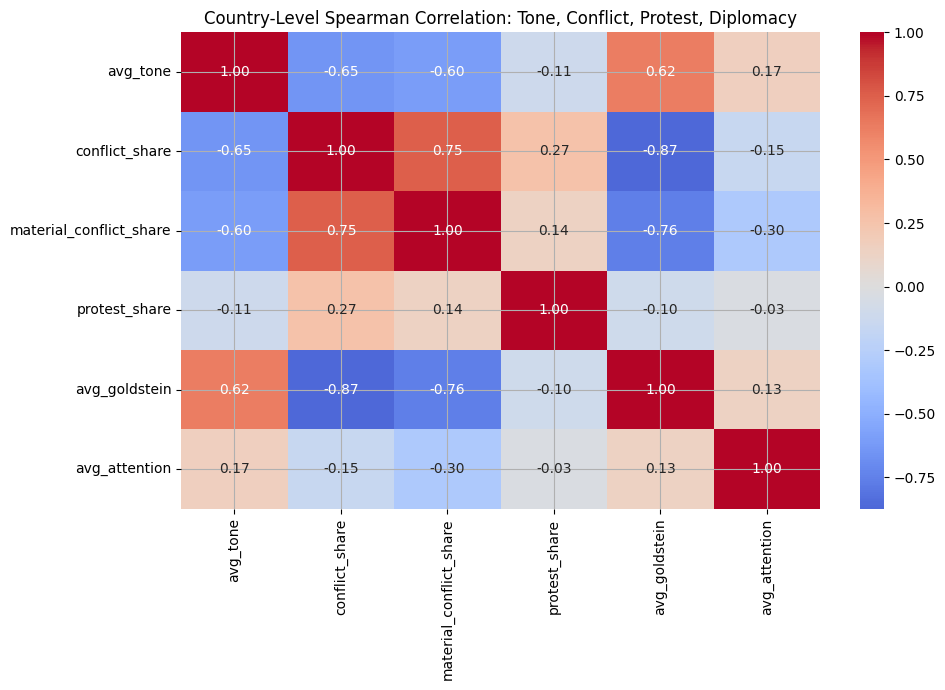

In [12]:
# ============================================================
# Cell 11: Correlation between tone and conflict indicators
# ============================================================

corr_cols = ["avg_tone", "conflict_share", "material_conflict_share", "protest_share", "avg_goldstein", "avg_attention"]
country_corr = country_stats[corr_cols].corr(method="spearman")

plt.figure(figsize=(10, 7))
sns.heatmap(country_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Country-Level Spearman Correlation: Tone, Conflict, Protest, Diplomacy")
plt.tight_layout()
plt.show()

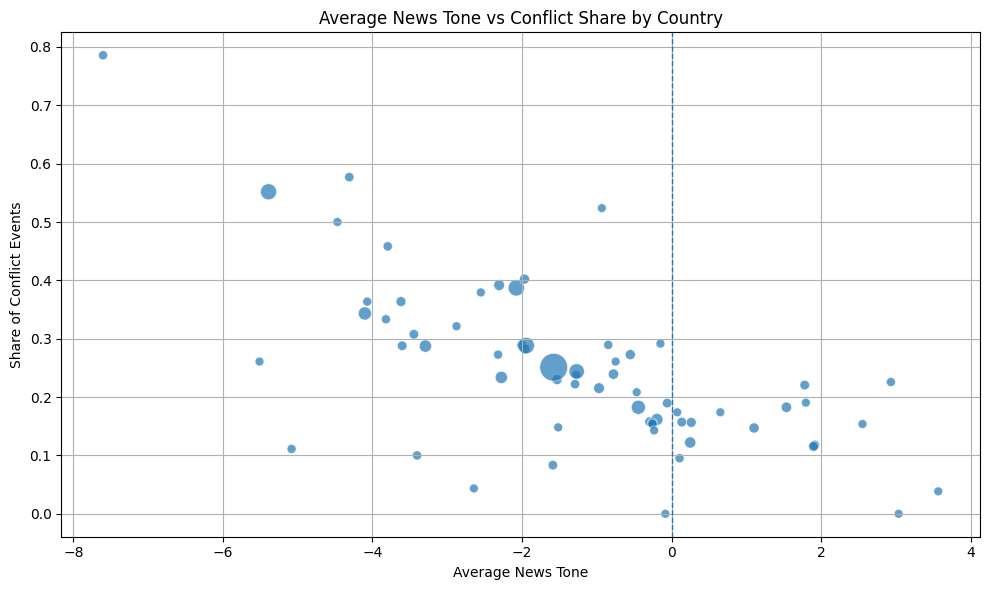

In [13]:
# ============================================================
# Cell 12: Scatter plot — average tone vs conflict share
# ============================================================

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=country_stats,
    x="avg_tone",
    y="conflict_share",
    size="events",
    sizes=(40, 400),
    alpha=0.7,
    legend=False
)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Average News Tone vs Conflict Share by Country")
plt.xlabel("Average News Tone")
plt.ylabel("Share of Conflict Events")
plt.tight_layout()
plt.show()


**Interpretation:** This scatter plot helps check whether countries with more negative average tone also have a higher share of conflict events. If the points do not form a clear pattern, the relationship should be interpreted as weak or uncertain, not as proof of causation.

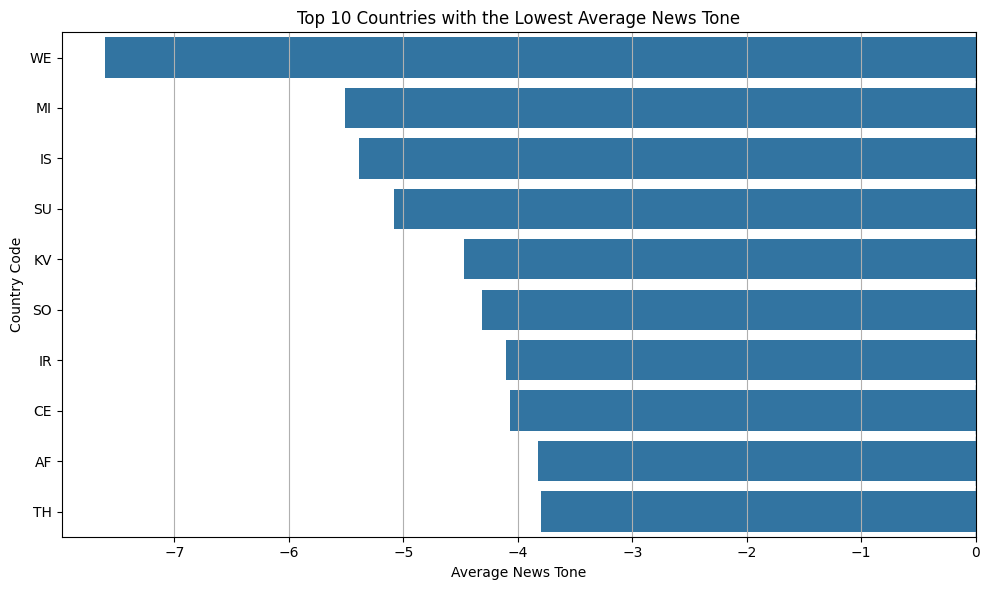

,ActionGeo_CountryCode,events,avg_tone,conflict_share,avg_goldstein
147,WE,42,-7.603502,0.785714,-5.697619
85,MI,23,-5.511148,0.260870,-0.473913
64,IS,618,-5.389526,0.551780,-2.622006
126,SU,36,-5.081531,0.111111,1.955556
74,KV,26,-4.468235,0.500000,-1.880769
124,SO,52,-4.310058,0.576923,-2.232692
63,IR,335,-4.101712,0.343284,-0.407463
25,CE,33,-4.069438,0.363636,-1.072727
1,AF,36,-3.819907,0.333333,0.041667
131,TH,48,-3.795710,0.458333,-2.345833


In [14]:
# ============================================================
# Cell 13: Bar chart — countries with the lowest average tone
# ============================================================

lowest_tone_countries = country_stats.sort_values("avg_tone").head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=lowest_tone_countries,
    x="avg_tone",
    y="ActionGeo_CountryCode"
)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Top 10 Countries with the Lowest Average News Tone")
plt.xlabel("Average News Tone")
plt.ylabel("Country Code")
plt.tight_layout()
plt.show()

lowest_tone_countries[["ActionGeo_CountryCode", "events", "avg_tone", "conflict_share", "avg_goldstein"]]


**Interpretation:** This bar chart highlights countries where the selected sample of news events has the lowest average tone. A low tone may reflect conflict, crisis, or negative media coverage, but it can also be affected by how often international media reports on a country.

# Analysis Question 2

## Which event types attract the most international media attention?

We rank event categories using:

- total events
- total mentions
- average number of sources
- average attention score
- average tone
- average Goldstein Scale

In [15]:
# ============================================================
# Cell 14: Event-category attention table
# ============================================================

category_stats = (
    df.groupby("event_category")
      .agg(
          events=("GLOBALEVENTID", "count"),
          avg_tone=("AvgTone", "mean"),
          avg_goldstein=("GoldsteinScale", "mean"),
          avg_mentions=("NumMentions", "mean"),
          total_mentions=("NumMentions", "sum"),
          avg_sources=("NumSources", "mean"),
          avg_articles=("NumArticles", "mean"),
          avg_attention=("attention_score", "mean"),
          conflict_share=("is_conflict", "mean")
      )
      .reset_index()
      .sort_values("avg_attention", ascending=False)
)

category_stats

,event_category,events,avg_tone,avg_goldstein,avg_mentions,total_mentions,avg_sources,avg_articles,avg_attention,conflict_share
7,Protest,89,-3.737065,-6.567416,6.685393,595,1.292135,6.573034,4.263170,1.0
4,Material Cooperation,524,-0.932343,6.986832,4.835878,2534,1.017176,4.803435,3.907471,0.0
6,Other Cooperation,2680,-2.112789,1.410112,4.502612,12067,1.038806,4.427985,3.766501,0.0
2,Diplomacy / Consultation,3247,-0.093097,2.856391,4.522636,14685,1.016939,4.383431,3.754256,0.0
0,Coercion,436,-5.835953,-5.275229,4.490826,1958,1.022936,4.348624,3.746217,1.0
5,Other Conflict,1363,-3.249567,-3.503888,4.509905,6147,1.025679,4.475422,3.740182,1.0
3,Engagement / Cooperation,1043,0.822196,4.073058,4.400767,4590,1.022052,4.302013,3.698553,0.0
1,Conflict / Violence,911,-4.994258,-9.766191,4.502744,4102,1.066959,4.310648,3.669033,1.0


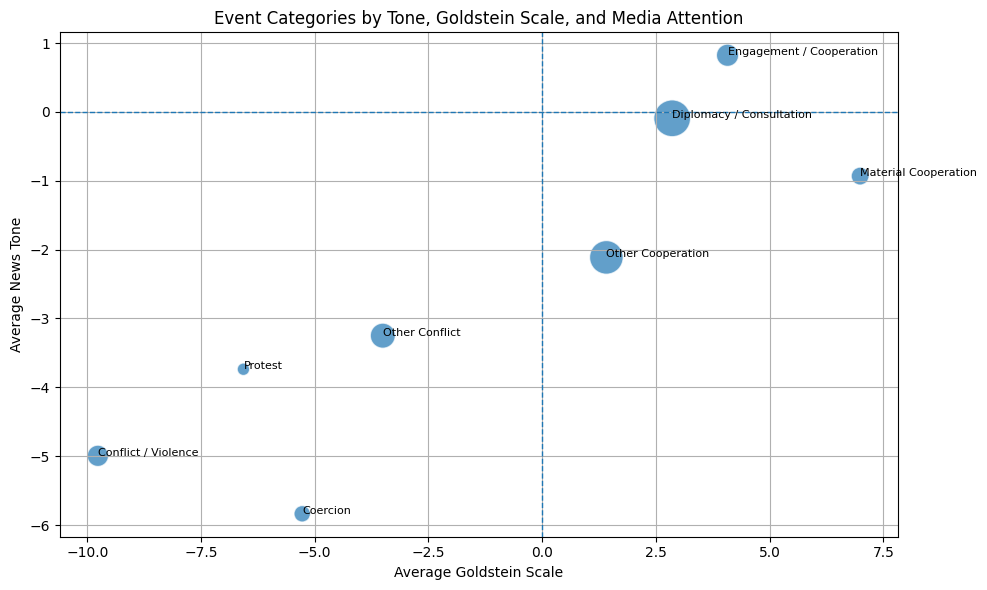

In [16]:
# ============================================================
# Cell 15: Scatter plot — media attention by event category
# ============================================================

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=category_stats,
    x="avg_goldstein",
    y="avg_tone",
    size="total_mentions",
    sizes=(80, 700),
    alpha=0.7,
    legend=False
)

for _, row in category_stats.iterrows():
    plt.text(row["avg_goldstein"], row["avg_tone"], row["event_category"], fontsize=8)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Event Categories by Tone, Goldstein Scale, and Media Attention")
plt.xlabel("Average Goldstein Scale")
plt.ylabel("Average News Tone")
plt.tight_layout()
plt.show()


**Interpretation:** This graph compares event categories using tone, Goldstein Scale, and media attention. Categories located closer to the negative side of the Goldstein Scale usually represent more conflict-oriented events, while cooperative categories tend to have more positive scores.

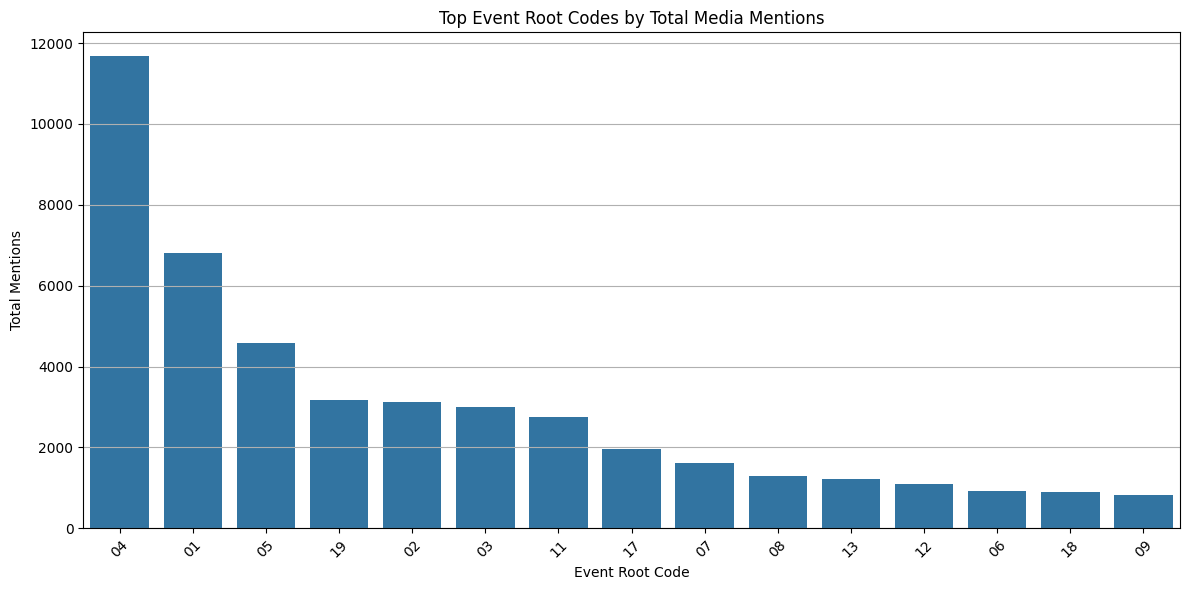

,EventRootCode,events,total_mentions,avg_tone,avg_goldstein
3,04,2582,11682,-0.151965,2.470798
0,01,1531,6812,-2.015004,0.033834
4,05,1043,4590,0.822196,4.073058
18,19,700,3176,-4.611878,-9.952857
1,02,676,3134,-1.791541,2.987130
2,03,665,3003,0.135469,4.353534
10,11,636,2741,-3.262076,-2.000000
16,17,436,1958,-5.835953,-5.275229
6,07,329,1607,-0.545680,7.360182
7,08,304,1291,-2.783175,6.730263


In [17]:
# ============================================================
# Cell 16: Bar chart — top event root codes by total mentions
# ============================================================

root_stats = (
    df.groupby("EventRootCode")
      .agg(
          events=("GLOBALEVENTID", "count"),
          total_mentions=("NumMentions", "sum"),
          avg_tone=("AvgTone", "mean"),
          avg_goldstein=("GoldsteinScale", "mean")
      )
      .reset_index()
      .sort_values("total_mentions", ascending=False)
      .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=root_stats, x="EventRootCode", y="total_mentions")
plt.title("Top Event Root Codes by Total Media Mentions")
plt.xlabel("Event Root Code")
plt.ylabel("Total Mentions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

root_stats

**Interpretation:** The bar chart shows which high-level event root codes receive the most media mentions. This helps identify the types of events that dominate the selected GDELT sample.

# Analysis Question 3

## Are diplomatic events reported with a different tone than protest or conflict events?

Here we compare distributions of `AvgTone` and `GoldsteinScale` across event categories.

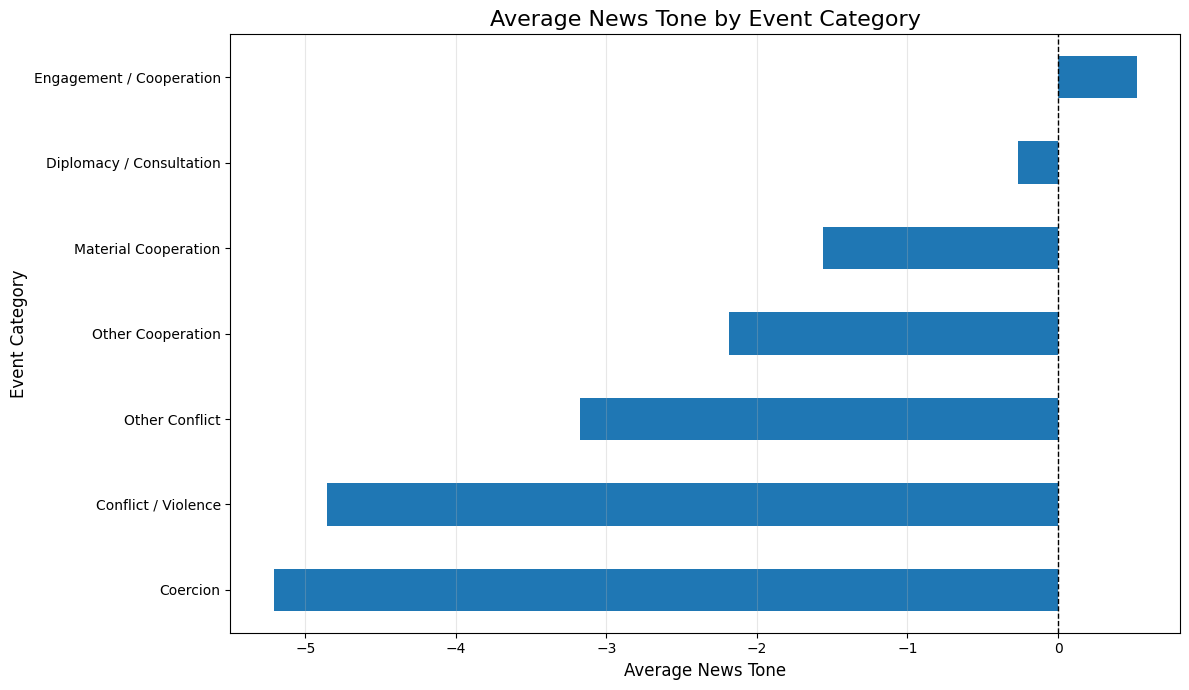

In [35]:
# ============================================================
# Cell 17: Average News Tone by Event Category
# ============================================================

# Keep only categories with enough observations
major_categories = (
    category_stats[category_stats["events"] >= 50]["event_category"]
    .tolist()
)

df_major = df[df["event_category"].isin(major_categories)].copy()

# Calculate average tone by category
tone_by_category = (
    df_major
    .groupby("event_category")["AvgTone"]
    .mean()
    .sort_values()
)

# Plot horizontal bar chart
plt.figure(figsize=(12, 7))

tone_by_category.plot(kind="barh")

# Add zero line to separate negative and positive tone
plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.title("Average News Tone by Event Category", fontsize=16)
plt.xlabel("Average News Tone", fontsize=12)
plt.ylabel("Event Category", fontsize=12)
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation:** The boxplot compares the distribution of news tone across event categories. This is useful because averages alone may hide variation inside each event type.

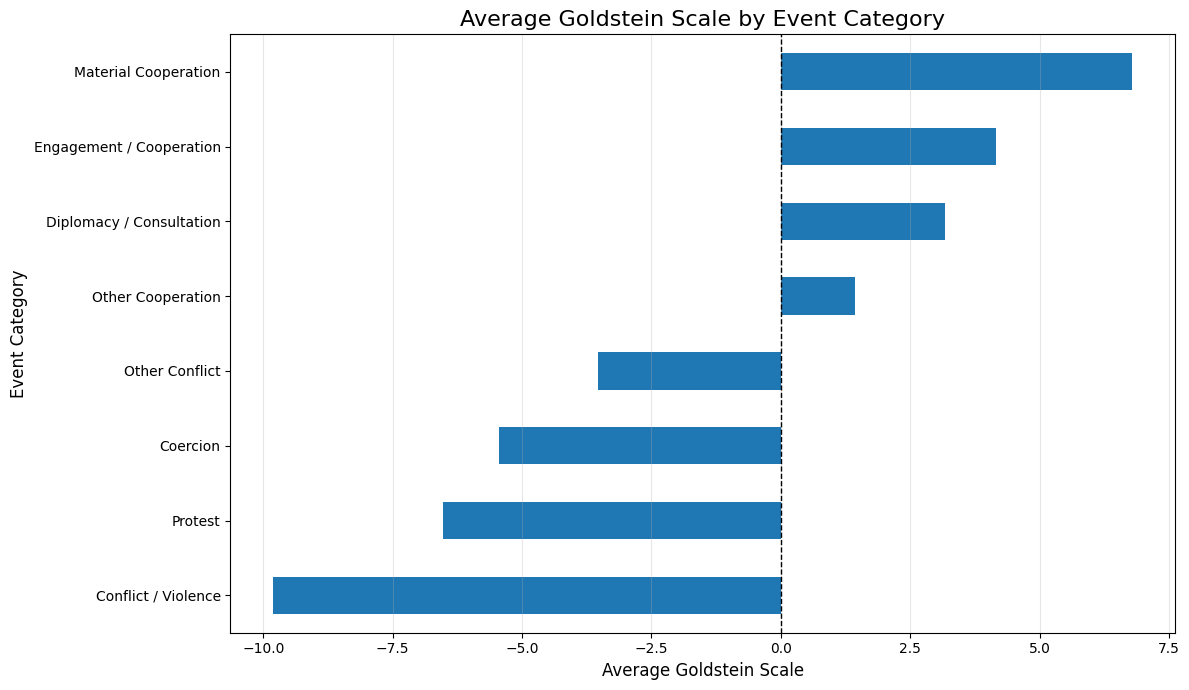

In [ ]:
# ============================================================
# Average Goldstein Scale by Event Category
# ============================================================

# Remove rows with missing values
goldstein_df = df.dropna(subset=["event_category", "GoldsteinScale"]).copy()

# Keep only the top 10 categories by number of events
top_categories = (
    goldstein_df["event_category"]
    .value_counts()
    .head(10)
    .index
)

goldstein_df = goldstein_df[
    goldstein_df["event_category"].isin(top_categories)
]

# Calculate average Goldstein Scale by event category
goldstein_avg = (
    goldstein_df
    .groupby("event_category")["GoldsteinScale"]
    .mean()
    .sort_values()
)

# Plot horizontal bar chart
plt.figure(figsize=(12, 7))

goldstein_avg.plot(kind="barh")

plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.title("Average Goldstein Scale by Event Category", fontsize=16)
plt.xlabel("Average Goldstein Scale", fontsize=12)
plt.ylabel("Event Category", fontsize=12)
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation:** The Goldstein Scale boxplot shows how cooperative or conflict-oriented each event category is. Negative values generally indicate more conflict-related behavior, while positive values indicate more cooperative behavior.

In [37]:
# ============================================================
# Cell 19: Summary comparison: diplomacy vs protest vs conflict
# ============================================================

comparison_groups = df[df["event_category"].isin([
    "Diplomacy / Consultation",
    "Engagement / Cooperation",
    "Protest",
    "Conflict / Violence",
    "Coercion"
])].copy()

comparison_summary = (
    comparison_groups.groupby("event_category")
    .agg(
        events=("GLOBALEVENTID", "count"),
        avg_tone=("AvgTone", "mean"),
        median_tone=("AvgTone", "median"),
        avg_goldstein=("GoldsteinScale", "mean"),
        avg_mentions=("NumMentions", "mean"),
        avg_sources=("NumSources", "mean")
    )
    .reset_index()
    .sort_values("avg_goldstein")
)

comparison_summary

,event_category,events,avg_tone,median_tone,avg_goldstein,avg_mentions,avg_sources
1,Conflict / Violence,772,-4.853567,-4.452830,-9.807642,5.205959,1.186528
4,Protest,41,-4.887153,-4.251386,-6.524390,3.951220,1.000000
0,Coercion,368,-5.210512,-5.687204,-5.451087,4.532609,1.035326
2,Diplomacy / Consultation,2984,-0.265554,-0.464037,3.179658,4.553284,1.020107
3,Engagement / Cooperation,813,0.523393,0.223214,4.159779,4.400984,1.019680


# Analysis Question 4

## How does global event intensity change across time?

We study:

- daily volume of events
- daily average tone
- daily conflict share
- hourly activity patterns

In [21]:
# ============================================================
# Cell 20: Daily time-series table
# ============================================================

daily = (
    df.groupby("event_date")
      .agg(
          events=("GLOBALEVENTID", "count"),
          avg_tone=("AvgTone", "mean"),
          conflict_share=("is_conflict", "mean"),
          protest_events=("is_protest", "sum"),
          diplomacy_events=("is_diplomacy", "sum"),
          total_mentions=("NumMentions", "sum"),
          avg_attention=("attention_score", "mean")
      )
      .reset_index()
      .sort_values("event_date")
)

daily["rolling_avg_tone"] = daily["avg_tone"].rolling(3, min_periods=1).mean()
daily["rolling_conflict_share"] = daily["conflict_share"].rolling(3, min_periods=1).mean()

daily.head()

,event_date,events,avg_tone,conflict_share,protest_events,diplomacy_events,total_mentions,avg_attention,rolling_avg_tone,rolling_conflict_share
0,2016-05-18,4,-3.244838,0.000000,0,4,20,3.988984,-3.244838,0.000000
1,2025-05-16,97,-2.150484,0.422680,5,33,335,3.350518,-2.697661,0.211340
2,2026-04-16,57,-1.816126,0.315789,0,21,180,3.267940,-2.403816,0.246157
3,2026-05-09,53,-1.034843,0.094340,0,35,153,3.125741,-1.667151,0.277603
4,2026-05-15,41,-2.605553,0.146341,0,15,189,3.848169,-1.818841,0.185490


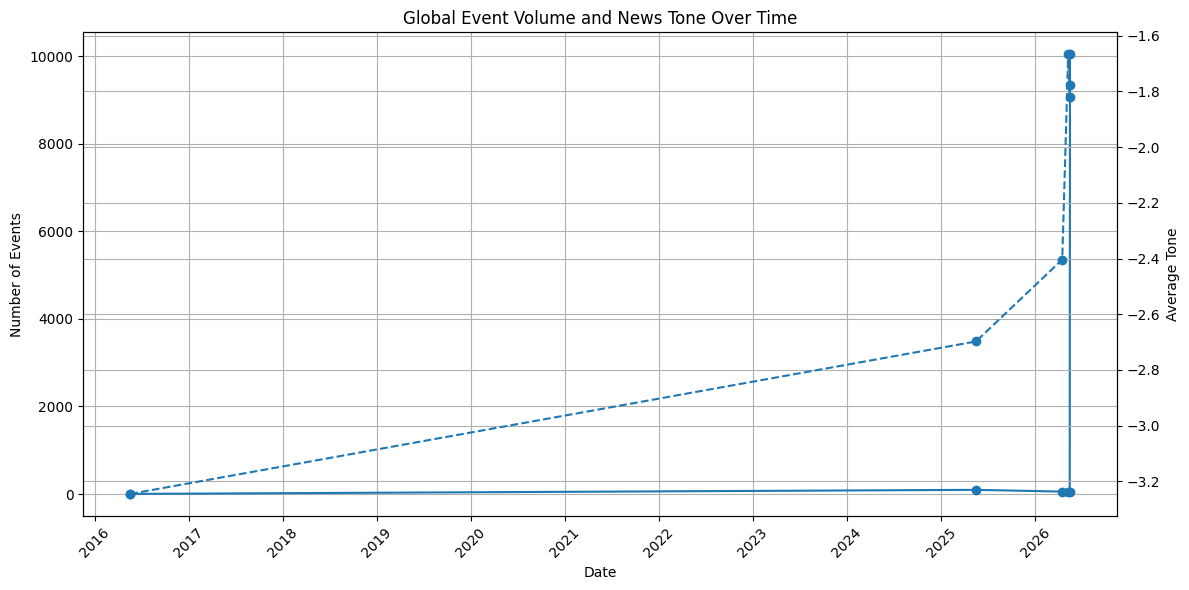

In [22]:
# ============================================================
# Cell 21: Line chart — events and average tone over time
# ============================================================

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(daily["event_date"], daily["events"], marker="o", label="Event Volume")
ax1.set_xlabel("Date")
ax1.set_ylabel("Number of Events")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(daily["event_date"], daily["rolling_avg_tone"], marker="o", linestyle="--", label="Rolling Avg Tone")
ax2.set_ylabel("Average Tone")

plt.title("Global Event Volume and News Tone Over Time")
fig.tight_layout()
plt.show()


**Interpretation:** This time-series graph compares event volume with average tone. Peaks in event volume may represent periods of stronger news activity, while the tone line shows whether the sample becomes more negative or positive over time.

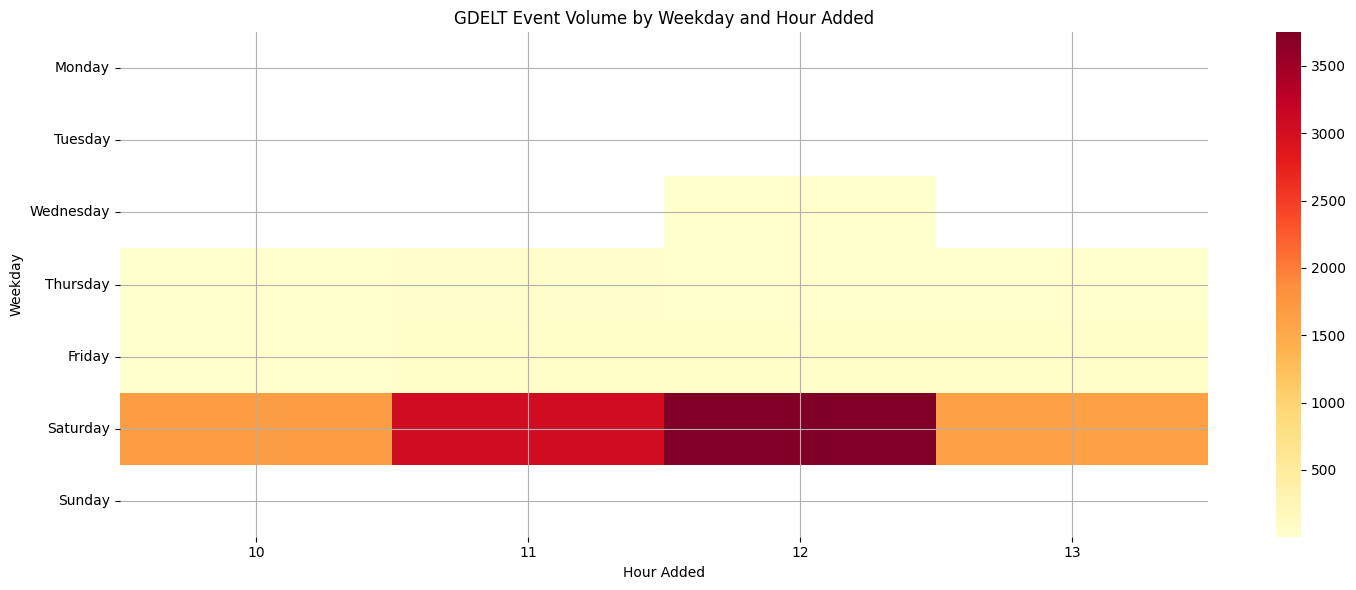

In [23]:
# ============================================================
# Cell 22: Heatmap — events by weekday and hour
# ============================================================

hour_weekday = (
    df.dropna(subset=["hour_added", "weekday"])
      .groupby(["weekday", "hour_added"])
      .size()
      .reset_index(name="events")
)

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

hour_pivot = hour_weekday.pivot(index="weekday", columns="hour_added", values="events")
hour_pivot = hour_pivot.reindex(weekday_order)

plt.figure(figsize=(15, 6))
sns.heatmap(hour_pivot, cmap="YlOrRd")
plt.title("GDELT Event Volume by Weekday and Hour Added")
plt.xlabel("Hour Added")
plt.ylabel("Weekday")
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap shows when events appear most often by weekday and hour. This is useful for understanding the time structure of the collected GDELT sample.

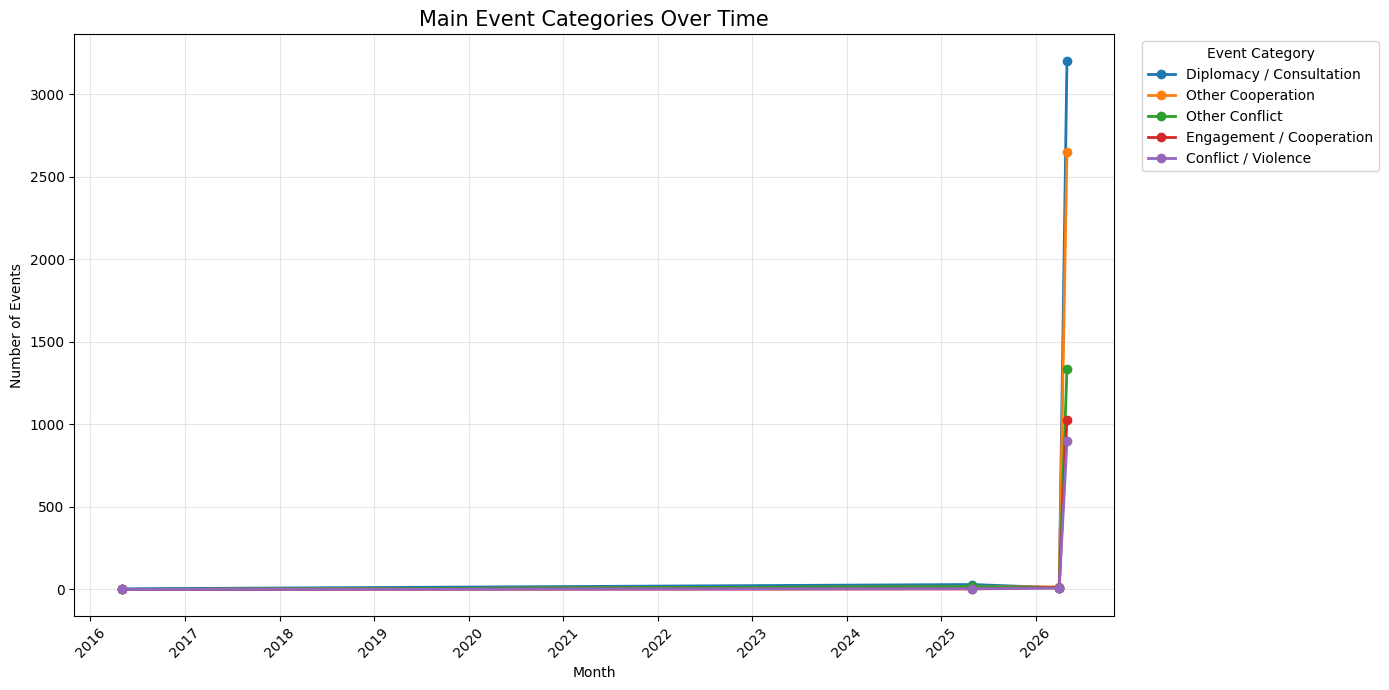

In [29]:
# ============================================================
# graph: Main Event Categories Over Time
# ============================================================

# Create monthly period for cleaner time visualization
df["event_month"] = df["event_date"].dt.to_period("M").dt.to_timestamp()

# Count events by month and event category
category_time = (
    df.groupby(["event_month", "event_category"])
      .size()
      .reset_index(name="events")
)

# Pivot table: months as rows, categories as columns
category_pivot = category_time.pivot(
    index="event_month",
    columns="event_category",
    values="events"
).fillna(0)

# Keep only the top 5 most frequent categories
main_categories = category_pivot.sum().sort_values(ascending=False).head(5).index

# Plot line chart instead of stacked area for better readability
plt.figure(figsize=(14, 7))

for category in main_categories:
    plt.plot(
        category_pivot.index,
        category_pivot[category],
        marker="o",
        linewidth=2,
        label=category
    )

plt.title("Main Event Categories Over Time", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Number of Events")
plt.legend(title="Event Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:** The stacked area chart shows how the main event categories change over time. It helps show whether conflict, diplomacy, protest, or cooperation dominates specific periods in the sample.

# Bonus Analysis

## Global Tension Index

We create a simple index using:

- negative tone
- conflict share
- material conflict share
- media attention
- inverse Goldstein score

This is not an official index. It is a student-created analytical metric for storytelling and ranking.

In [25]:
# ============================================================
# Cell 24: Build country-level Global Tension Index
# ============================================================

# This is a simple student-created index. It avoids advanced ML preprocessing
# and uses only pandas/numpy operations.
tension = country_stats.copy()

tension["negative_tone_score"] = np.maximum(-tension["avg_tone"], 0)
tension["inverse_goldstein"] = np.maximum(-tension["avg_goldstein"], 0)

index_features = [
    "negative_tone_score",
    "conflict_share",
    "material_conflict_share",
    "avg_attention",
    "inverse_goldstein"
]

# Min-max scale each component to 0-1 before averaging.
for col in index_features:
    min_value = tension[col].min()
    max_value = tension[col].max()
    if max_value != min_value:
        tension[col + "_scaled"] = (tension[col] - min_value) / (max_value - min_value)
    else:
        tension[col + "_scaled"] = 0

scaled_cols = [col + "_scaled" for col in index_features]
tension["global_tension_index_0_100"] = tension[scaled_cols].mean(axis=1) * 100

tension_ranked = tension.sort_values("global_tension_index_0_100", ascending=False)

tension_ranked.head(15)


,ActionGeo_CountryCode,events,avg_tone,median_tone,conflict_share,material_conflict_share,protest_share,diplomacy_share,avg_goldstein,avg_attention,total_mentions,negative_tone_score,inverse_goldstein,negative_tone_score_scaled,conflict_share_scaled,material_conflict_share_scaled,avg_attention_scaled,inverse_goldstein_scaled,global_tension_index_0_100
147,WE,42,-7.603502,-7.943262,0.785714,0.642857,0.000000,0.071429,-5.697619,3.271192,136,7.603502,5.697619,1.000000,1.000000,1.000000,0.122888,1.000000,82.457753
64,IS,618,-5.389526,-6.007067,0.551780,0.368932,0.001618,0.239482,-2.622006,3.596023,2555,5.389526,2.622006,0.708821,0.702265,0.573894,0.266642,0.460193,54.236321
25,CE,33,-4.069438,-2.232143,0.363636,0.272727,0.000000,0.242424,-1.072727,5.253143,445,4.069438,1.072727,0.535206,0.462810,0.424242,1.000000,0.188276,52.210691
131,TH,48,-3.795710,-4.689753,0.458333,0.375000,0.020833,0.125000,-2.345833,3.940634,238,3.795710,2.345833,0.499206,0.583333,0.583333,0.419149,0.411722,49.934860
124,SO,52,-4.310058,-4.536391,0.576923,0.250000,0.038462,0.173077,-2.232692,3.784914,239,4.310058,2.232692,0.566852,0.734266,0.388889,0.350235,0.391864,48.642117
74,KV,26,-4.468235,-4.054054,0.500000,0.384615,0.076923,0.500000,-1.880769,3.332178,86,4.468235,1.880769,0.587655,0.636364,0.598291,0.149877,0.330097,46.045668
68,JM,21,-0.932599,-1.372213,0.523810,0.190476,0.000000,0.285714,-1.985714,4.233266,114,0.932599,1.985714,0.122654,0.666667,0.296296,0.548653,0.348517,39.655735
85,MI,23,-5.511148,-5.833333,0.260870,0.043478,0.000000,0.260870,-0.473913,4.326792,130,5.511148,0.473913,0.724817,0.332016,0.067633,0.590043,0.083177,35.953725
63,IR,335,-4.101712,-3.253796,0.343284,0.182090,0.005970,0.340299,-0.407463,3.571026,1361,4.101712,0.407463,0.539450,0.436906,0.283250,0.255579,0.071515,31.734020
1,AF,36,-3.819907,-5.563835,0.333333,0.194444,0.027778,0.444444,0.041667,3.757616,151,3.819907,0.000000,0.502388,0.424242,0.302469,0.338155,0.000000,31.345085


In [ ]:
# ============================================================
# Cell 25: Bar chart — top countries by Global Tension Index
# ============================================================

top_tension = tension_ranked.head(15)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_tension,
    x="global_tension_index_0_100",
    y="ActionGeo_CountryCode"
)
plt.title("Top Countries by Student-Created Global Tension Index")
plt.xlabel("Global Tension Index, 0-100")
plt.ylabel("Country Code")
plt.tight_layout()
plt.show()

**Interpretation:** The Global Tension Index is a simple descriptive score created for this project. Countries with higher values combine more negative tone, higher conflict share, stronger media attention, and lower Goldstein scores.

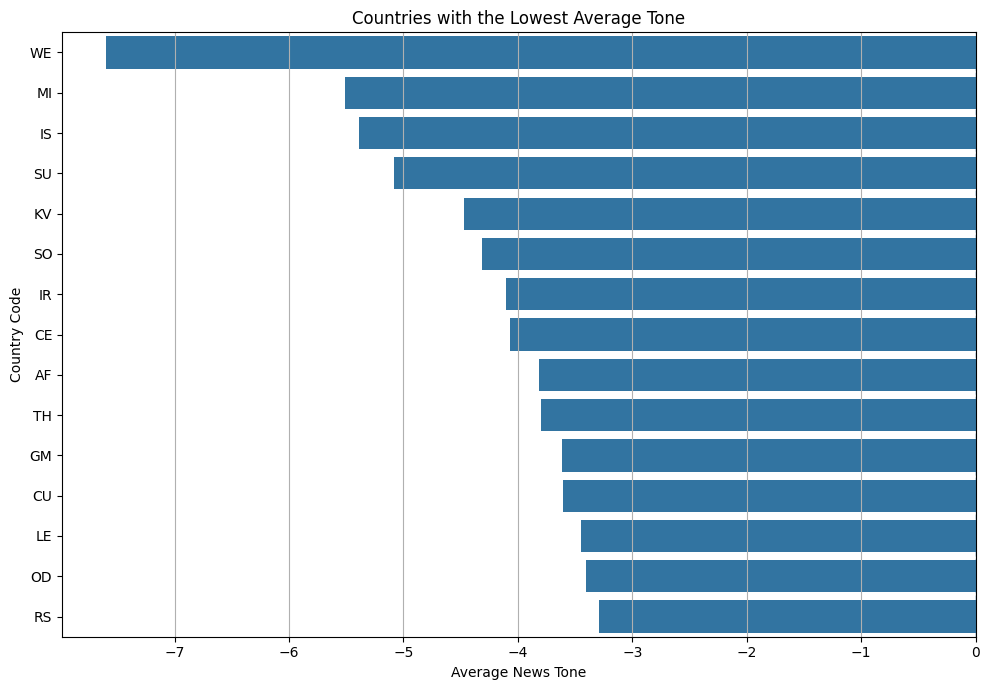

In [ ]:
# ============================================================
# Cell 26: Bar chart — lowest average tone among ranked countries
# ============================================================

tone_rank = tension.sort_values("avg_tone").head(15)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=tone_rank,
    x="avg_tone",
    y="ActionGeo_CountryCode"
)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Countries with the Lowest Average Tone")
plt.xlabel("Average News Tone")
plt.ylabel("Country Code")
plt.tight_layout()
plt.show()


**Interpretation:** This chart focuses specifically on average tone by country. It is included as a lecture-friendly replacement for an advanced interactive map.

In [36]:
# ============================================================
# Cell 29: Export cleaned data and summary tables
# ============================================================

OUTPUT_DIR = Path("gdelt_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

df.to_csv(OUTPUT_DIR / "cleaned_gdelt_events_sample.csv", index=False)
country_stats.to_csv(OUTPUT_DIR / "country_mood_conflict_stats.csv", index=False)
category_stats.to_csv(OUTPUT_DIR / "event_category_attention_stats.csv", index=False)
daily.to_csv(OUTPUT_DIR / "daily_event_intensity_stats.csv", index=False)
tension_ranked.to_csv(OUTPUT_DIR / "global_tension_index_country_ranking.csv", index=False)

print("Export complete.")
print(f"Files saved in: {OUTPUT_DIR.resolve()}")

Export complete.
Files saved in: /Users/beltinaa/Documents/world_mood_map_notebook/gdelt_outputs


# Conclusion 

> This project used GDELT 2.0 news event data to examine whether global news tone is related to protest, conflict, diplomacy, and media attention. The results show that tone, Goldstein Scale, event category, and media attention can be combined to identify countries and event types that appear more tense or more cooperative in the news ecosystem. However, because GDELT is based on media reporting, the findings should be interpreted as patterns of reported global events rather than perfect measurements of reality.

